In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# MRS - Klasifikacija EEG podatkov pred in po zaužitju kave

## 1. Uvod

**Problem**, ki ga bom obravnaval v tem projektu, je **binarna klasifikacija** EEG podatkov na pred in po zaužitju kave.

**Cilj** je doseči čim večjo preciznost pri klasifikaciji EEG podatkov na pred in po zaužitju kave.

**Načrt postopka rešitve** vključuje naslednje korake:
1. **Deskriptivna statistika**: Pregled in grafični prikaz osnovnih značilnosti podatkov.
2. **Razdelitev podatkov**: Podatke bom razdelil na učni in testni sklop, da bom lahko preveril učinkovitost modela.
3. **Izbira modela**: Uporabljeni bodo različni algoritmi za klasifikacijo.
4. **Učenje modela**: Učenje modela na učni in testni množici.
5. **Evalvacija modela**: Vrednotenje uspešnosti modela bo izvedeno z uporabo kazalnikov, kot so točnost, preciznost, priklic in F1-ocena.
6. **Optimizacija modela**: Optimizacija hiperparametrov, če bo potrebna.
7. **Primerjava modelov**: Primerjava uspešnosti modelov.

## 2. Opis podatkov

Podatke so shranjeni v strukturi **ALLEEG**, ki je uporabljena za organizacijo več EEG datasetov (podatkov več udeležencev) in njihovo obdelavo v enem samem okolju (Slika 3). Ta struktura je del dokumentacije **EEGLABa**.

**ALLEEG** zajema veliko podatkov, najpomembnejši za nas so:

- **subject**: šifra udeleženca
- **condition/group**: eksperimentalni pogoj/eksperimentalna skupina
- **trials**: število epoh
- **pnts**: število podatkovnih točk pri vsaki epohi
- **srate**: predstavlja frekvenco vzorčenja. Recimo, da smo pri zajemu podatkov frekvenco vzorčenja nastavili na 500 Hz. To pomeni, da smo zajeli 500 podatkovnih točk na sekundo, ali drugače, eno podatkovno točko na 2 milisekundi.
- **xmin**: začetek epohe. Npr. -0.1000 pomeni, da se epoha začne 100 ms pred markerjem.
- **xmax**: konec epohe. Npr. 1.998 pomeni, da se epoha konča 1998 ms po markerju (približno 2 sekundi).
- **data**: podatki v 3D formatu `[število elektrod × število podatkovnih točk v posamezni epohi × število epoh]` (npr. 32 elektrod × 1260 podatkovnih točk × 100 epoh). To omogoča dostop do časovnih serij za vsako elektrodo in epoho.
- **chanlocs**: imena in lokacije elektrod
- **event**: Vsebuje informacije o markerjih (tip eksperimentalnega pogoja, latenca,...). Te oznake so ključne za povezavo posameznih epoh s specifičnimi eksperimentalnimi pogoji.
- **epoch**: Vsebuje informacije o posameznih epohah, vključno z eksperimentalnim pogojem in drugimi podatki (npr. identifikacijsko številko dogodka, ki je epohi pripisana).

In [3]:
# Naloži .mat datoteko
data = loadmat("../data/raw/Caffeine_data_20250311.mat")

# Pregledovanje ključev
print(data.keys())

ALLEEG = data['ALLEEG']
print(ALLEEG[0, 0].dtype.names)  # Vsa polja v ALEEG

dict_keys(['__header__', '__version__', '__globals__', 'ALLEEG'])
('setname', 'filename', 'filepath', 'subject', 'group', 'condition', 'session', 'comments', 'nbchan', 'trials', 'pnts', 'srate', 'xmin', 'xmax', 'times', 'data', 'icaact', 'icawinv', 'icasphere', 'icaweights', 'icachansind', 'chanlocs', 'urchanlocs', 'chaninfo', 'ref', 'event', 'urevent', 'eventdescription', 'epoch', 'epochdescription', 'reject', 'stats', 'specdata', 'specicaact', 'splinefile', 'icasplinefile', 'dipfit', 'history', 'saved', 'etc', 'run', 'datfile', 'roi')


In [6]:
# Pregled subjektov
raw_data = {}
for i in range(ALLEEG.size):
    subject = ALLEEG[0, i]['subject'][0]
    condition = ALLEEG[0, i]['condition'][0]
    srate = ALLEEG[0, i]['srate'][0][0]
    data = ALLEEG[0, i]['data']
    group = ALLEEG[0, i]['group'][0]

    raw_data[(subject, condition)] = data
    print(i + 1, f"Subject: {subject}, Group: {group}, Condition: {condition}, Sampling Rate: {srate}, Data Shape: {data.shape}") # (electrodes, timepoints, epochs)

1 Subject: 311, Group: Caffeine, Condition: After, Sampling Rate: 600, Data Shape: (32, 900, 100)
2 Subject: 311, Group: Caffeine, Condition: Before, Sampling Rate: 600, Data Shape: (32, 900, 100)
3 Subject: 315, Group: Caffeine, Condition: After, Sampling Rate: 600, Data Shape: (32, 900, 99)
4 Subject: 315, Group: Caffeine, Condition: Before, Sampling Rate: 600, Data Shape: (32, 900, 100)
5 Subject: 318, Group: Placebo, Condition: After, Sampling Rate: 600, Data Shape: (32, 900, 100)
6 Subject: 318, Group: Placebo, Condition: Before, Sampling Rate: 600, Data Shape: (32, 900, 100)
7 Subject: 340, Group: Caffeine, Condition: After, Sampling Rate: 600, Data Shape: (32, 900, 100)
8 Subject: 340, Group: Caffeine, Condition: Before, Sampling Rate: 600, Data Shape: (32, 900, 100)
9 Subject: 342, Group: Caffeine, Condition: After, Sampling Rate: 600, Data Shape: (32, 900, 100)
10 Subject: 342, Group: Caffeine, Condition: Before, Sampling Rate: 600, Data Shape: (32, 900, 96)
11 Subject: 346, G

In [4]:
for i in range(ALLEEG.size):
    eeg = ALLEEG[0, i]

    subject = eeg['subject'][0]
    condition = eeg['condition'][0]
    group = eeg['group'][0] if 'group' in eeg.dtype.names else "N/A"

    srate = eeg['srate'][0][0]
    trials = eeg['trials'][0][0]
    pnts = eeg['pnts'][0][0]

    xmin = eeg['xmin'][0][0]
    xmax = eeg['xmax'][0][0]

    data = eeg['data']
    n_channels = data.shape[0]

    # imena elektrod
    chanlocs = eeg['chanlocs']
    channel_names = [chanlocs[0][j]['labels'][0] for j in range(len(chanlocs[0]))]

    print(f"\n--- Dataset {i+1} ---")
    print(f"Subject: {subject}")
    print(f"Condition: {condition} | Group: {group}")
    print(f"Channels: {n_channels} ({channel_names[:5]} ...)")
    print(f"Epochs (trials): {trials}")
    print(f"Timepoints per epoch: {pnts}")
    print(f"Sampling rate: {srate} Hz")
    print(f"Epoch duration: {xmin:.3f}s → {xmax:.3f}s ({xmax - xmin:.2f}s)")
    print(f"Data shape: {data.shape}")


--- Dataset 1 ---
Subject: 311
Condition: After | Group: Caffeine
Channels: 32 ([np.str_('Fp1'), np.str_('Fp2'), np.str_('AF3'), np.str_('AF4'), np.str_('F7')] ...)
Epochs (trials): 100
Timepoints per epoch: 1260
Sampling rate: 600 Hz
Epoch duration: -0.100s → 1.998s (2.10s)
Data shape: (32, 900, 100)

--- Dataset 2 ---
Subject: 311
Condition: Before | Group: Caffeine
Channels: 32 ([np.str_('Fp1'), np.str_('Fp2'), np.str_('AF3'), np.str_('AF4'), np.str_('F7')] ...)
Epochs (trials): 100
Timepoints per epoch: 1260
Sampling rate: 600 Hz
Epoch duration: -0.100s → 1.998s (2.10s)
Data shape: (32, 900, 100)

--- Dataset 3 ---
Subject: 315
Condition: After | Group: Caffeine
Channels: 32 ([np.str_('Fp1'), np.str_('Fp2'), np.str_('AF3'), np.str_('AF4'), np.str_('F7')] ...)
Epochs (trials): 99
Timepoints per epoch: 1260
Sampling rate: 600 Hz
Epoch duration: -0.100s → 1.998s (2.10s)
Data shape: (32, 900, 99)

--- Dataset 4 ---
Subject: 315
Condition: Before | Group: Caffeine
Channels: 32 ([np.str

In [7]:
n_timepoints = data.shape[1]
duration_from_data = n_timepoints / srate

duration_from_meta = xmax - xmin

print(f"Duration from data: {duration_from_data:.2f} s")
print(f"Duration from metadata: {duration_from_meta:.2f} s")

Duration from data: 1.50 s
Duration from metadata: 2.10 s


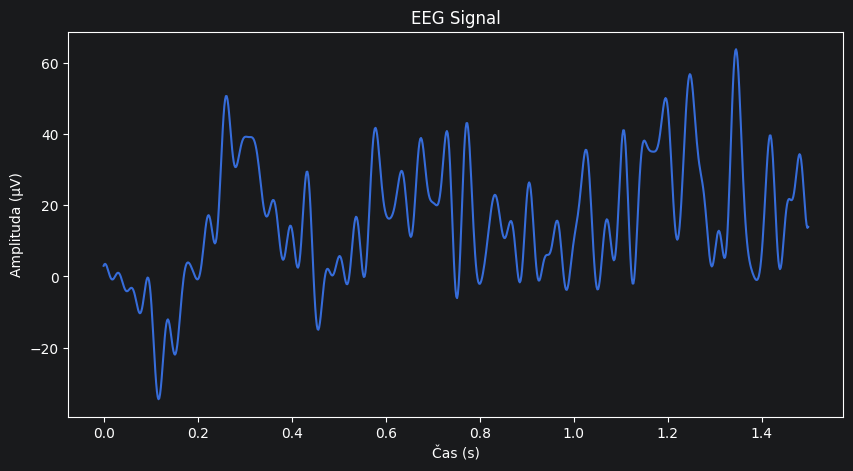

In [5]:
# Elektroda 1
channel_idx = 0  #
epoch_idx = 0
signal = ALLEEG[0, 0]['data'][channel_idx, :, epoch_idx]
time = np.arange(signal.shape[0]) / 600

plt.figure(figsize=(10, 5))
plt.plot(time, signal)
plt.title(f"EEG Signal")
plt.xlabel("Čas (s)")
plt.ylabel("Amplituda (μV)")
plt.show()

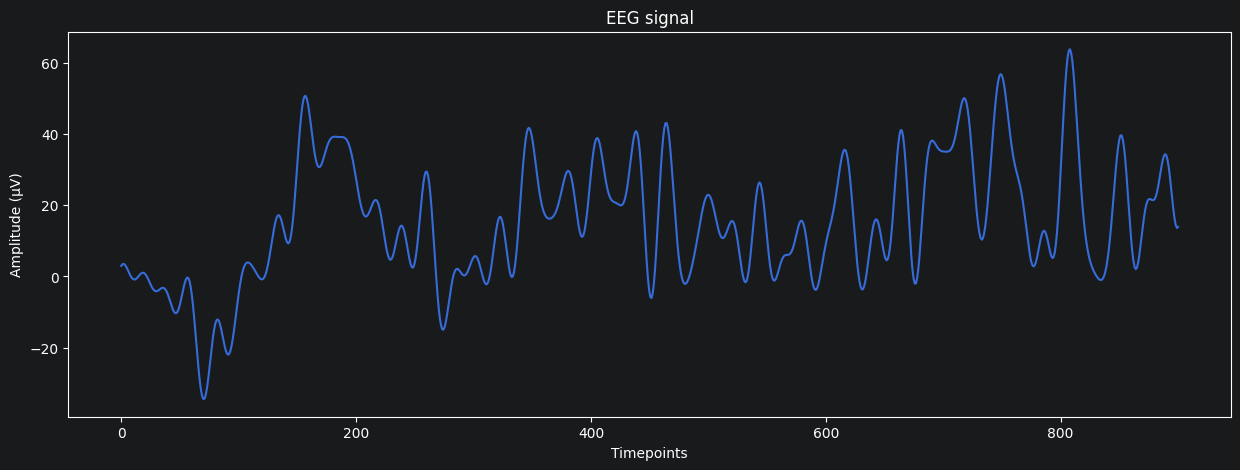

In [6]:
# Elektroda 1
channel_idx = 0

signal = ALLEEG[0,0]['data'][channel_idx,:,0]  # one epoch

n_times = signal.shape[0]

timepoints = np.linspace(0, 900, n_times)

plt.figure(figsize=(15,5))
plt.plot(timepoints, signal)
plt.xlabel("Timepoints")
plt.ylabel("Amplitude (µV)")
plt.title("EEG signal")
plt.show()